In [1]:
! pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"carolinanaomialvarez","key":"c6d6d3c3f2881896909ebf907a86df82"}'}

In [2]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [3]:
! chmod 600 ~/.kaggle/kaggle.json

In [4]:
! kaggle competitions download -c playground-series-s5e8

playground-series-s5e8.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
# directory for train
! mkdir train
! unzip playground-series-s5e8.zip -d train

mkdir: cannot create directory ‘train’: File exists
Archive:  playground-series-s5e8.zip
replace train/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train/sample_submission.csv  
replace train/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train/test.csv          
replace train/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train/train.csv         


# **Binary Classification with a Bank Dataset**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/content/train/train.csv')
df

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,29,services,single,secondary,no,1282,no,yes,unknown,4,jul,1006,2,-1,0,unknown,1
749996,749996,69,retired,divorced,tertiary,no,631,no,no,cellular,19,aug,87,1,-1,0,unknown,0
749997,749997,50,blue-collar,married,secondary,no,217,yes,no,cellular,17,apr,113,1,-1,0,unknown,0
749998,749998,32,technician,married,secondary,no,-274,no,no,cellular,26,aug,108,6,-1,0,unknown,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [9]:
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,216506.495284,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,0.000000,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,187499.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,374999.500000,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,562499.250000,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,749999.000000,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [10]:
# duplictes
df['id'].duplicated().sum()

np.int64(0)

# Int Columns

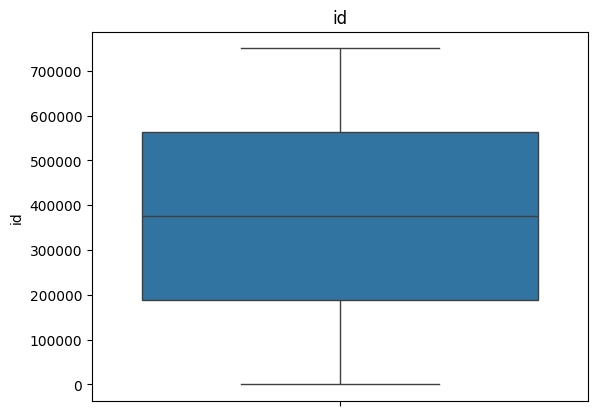

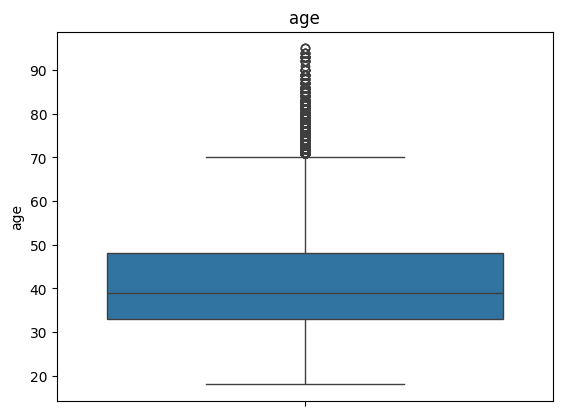

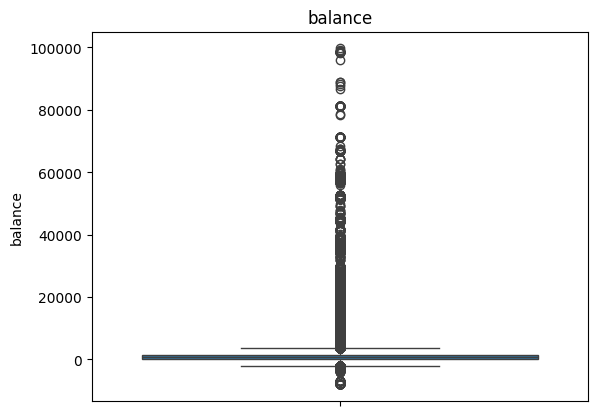

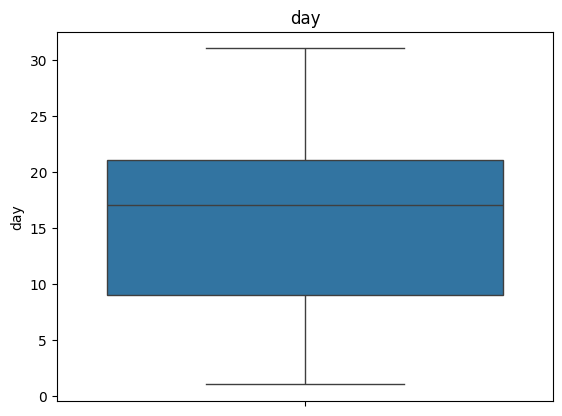

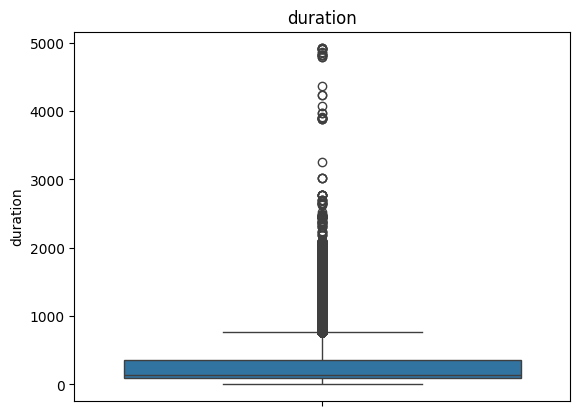

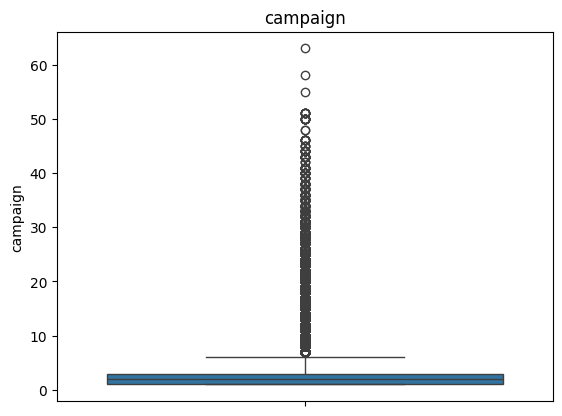

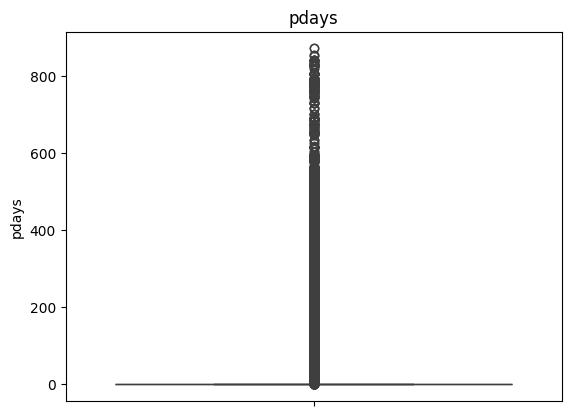

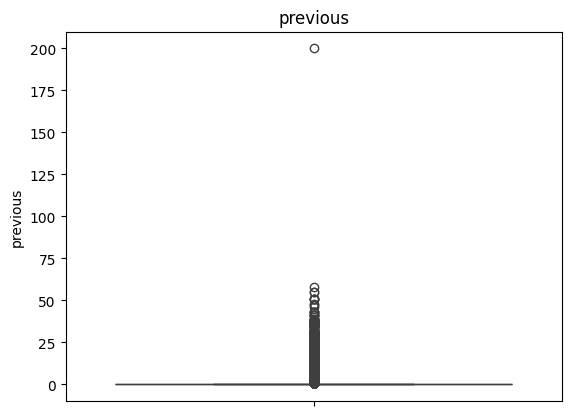

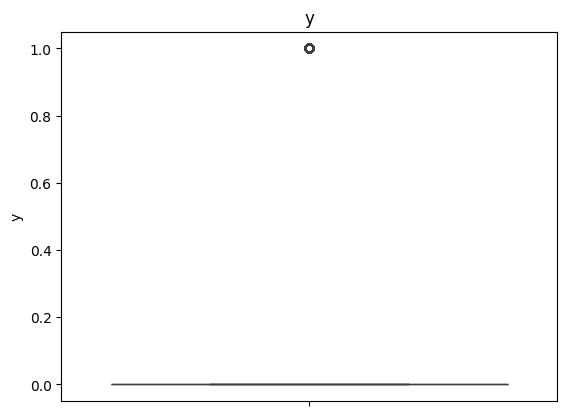

In [11]:
# boxplot for each int column
for col in df.select_dtypes(include=['int64']):
    plt.figure()
    sns.boxplot(df[col])
    plt.title(col)

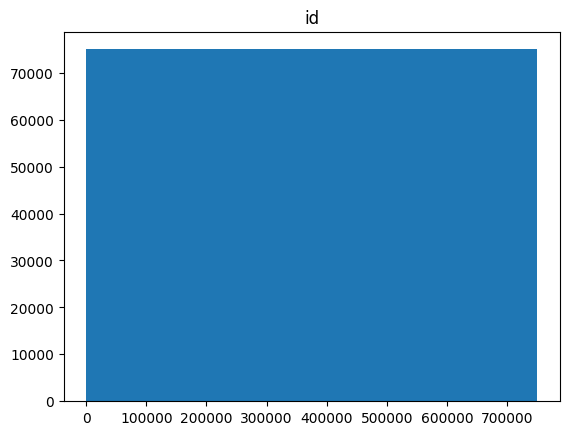

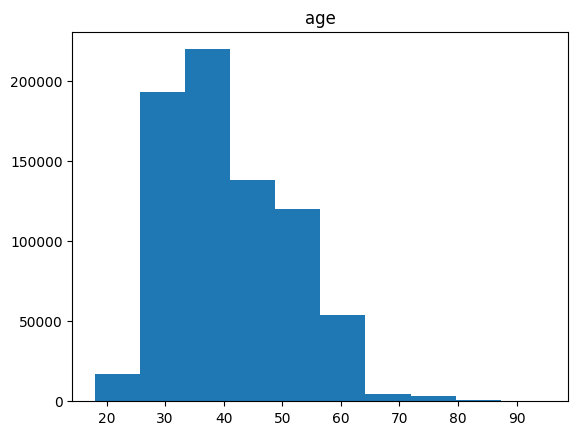

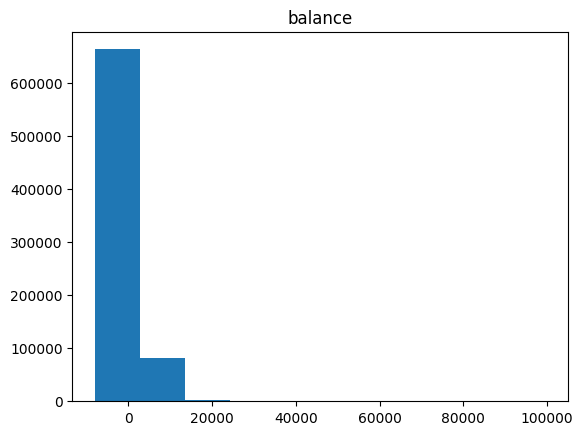

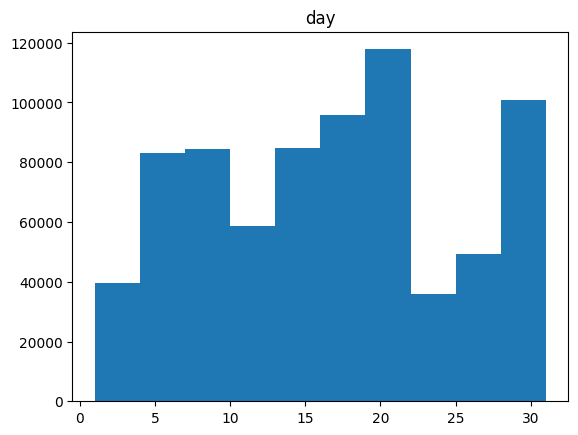

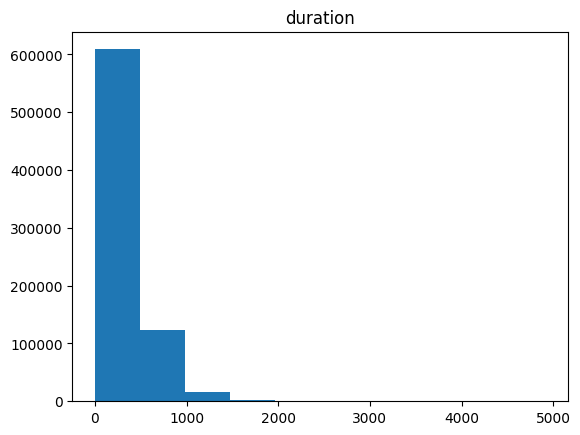

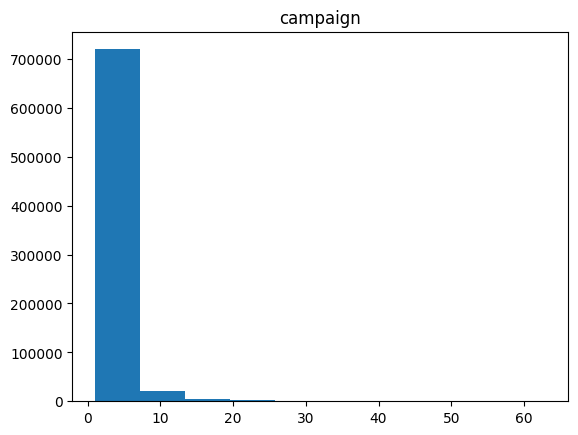

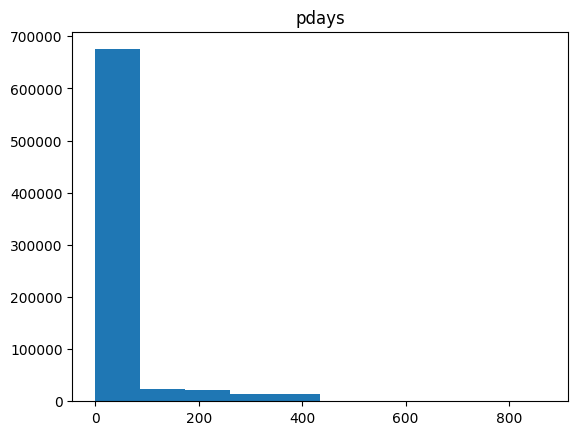

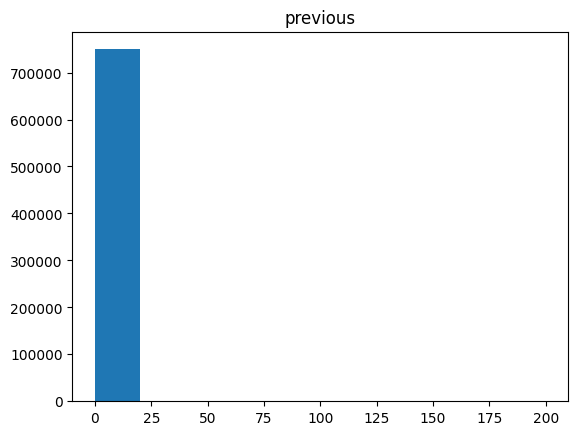

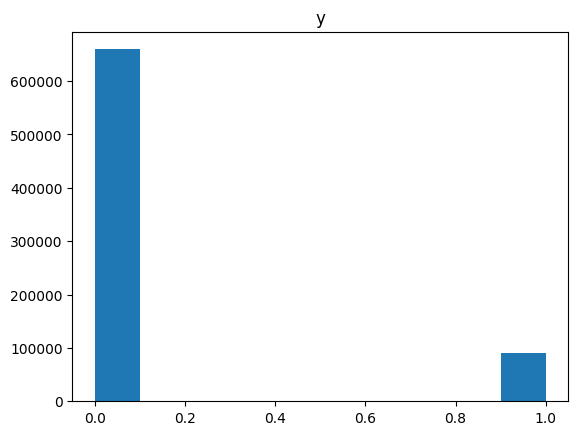

In [12]:
# hist for each int columns
for col in df.select_dtypes(include=['int64']):
    plt.figure()
    plt.hist(df[col])
    plt.title(col)

# object columns

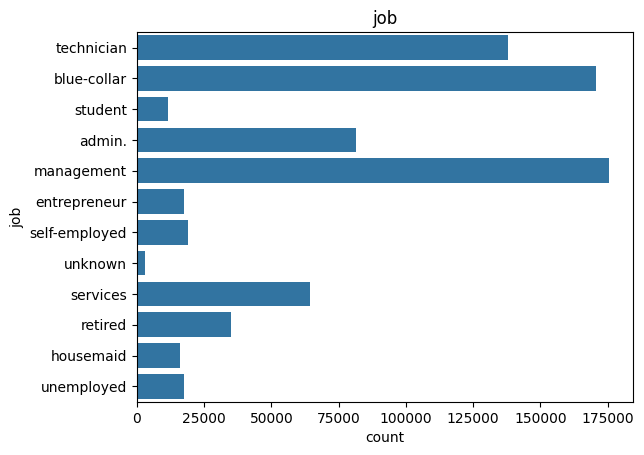

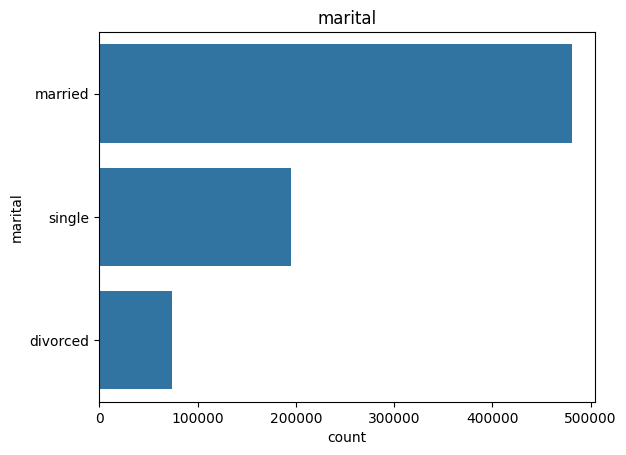

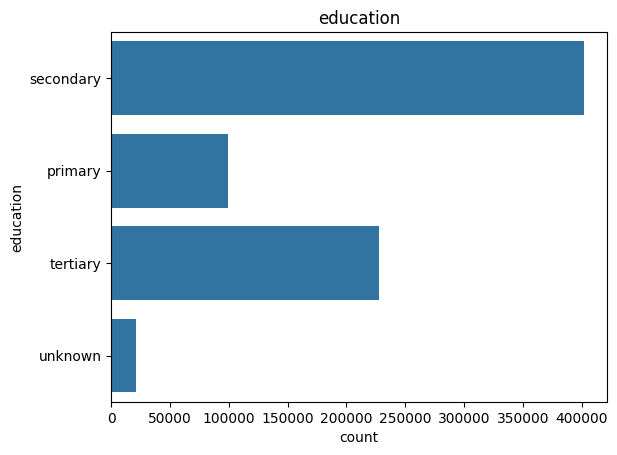

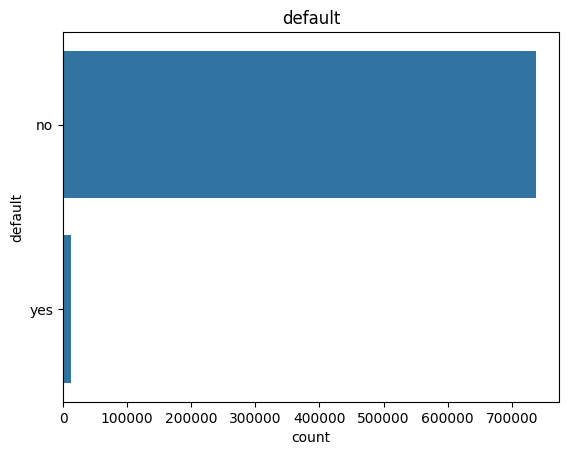

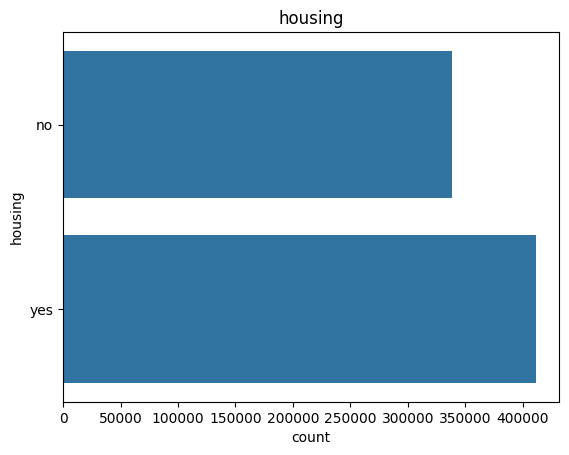

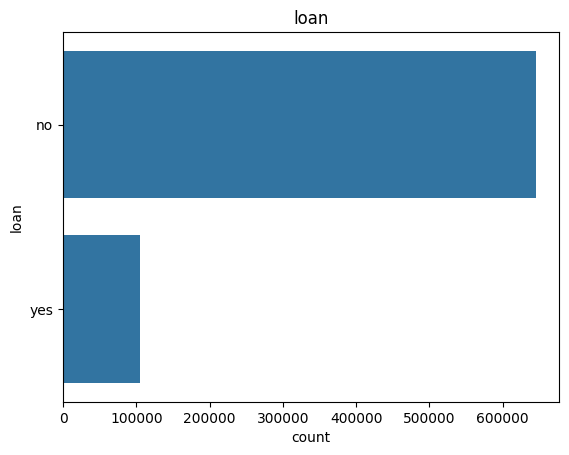

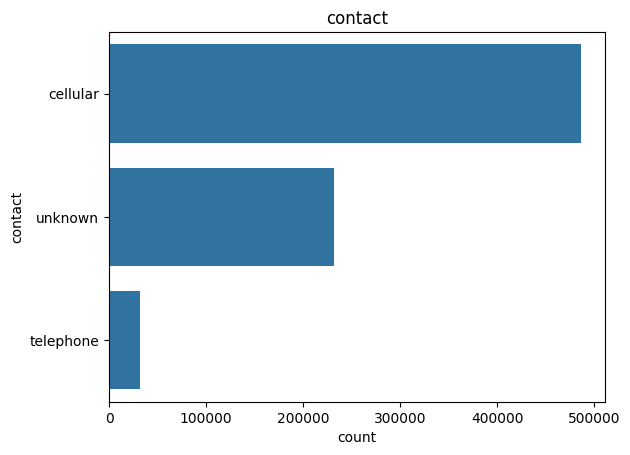

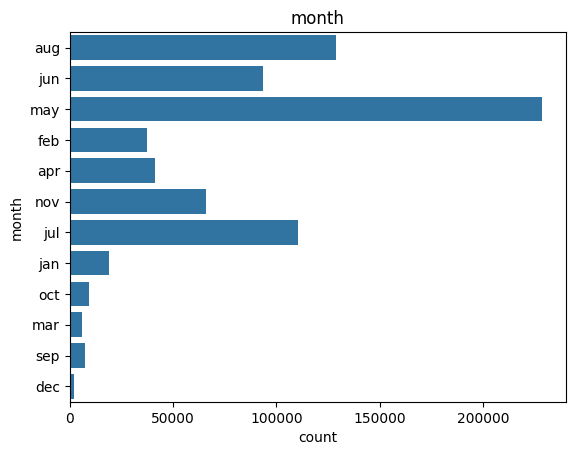

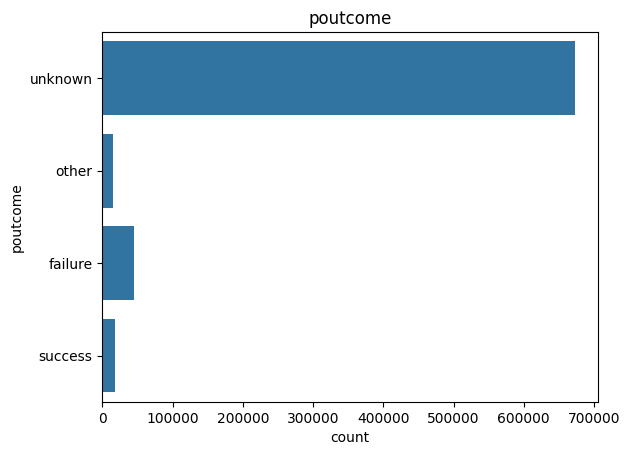

In [13]:
# graph frecuency in each object columns
for col in df.select_dtypes(include=['object']):
    plt.figure()
    sns.countplot(df[col])
    plt.title(col)
# remove unknown from job, education?
# is default,loan,potcome important

# **Feature engineering**

In [14]:
# label encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

#each object column
for col in df.select_dtypes(include=['object']):
    df[col] = le.fit_transform(df[col])

In [15]:
df

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,9,1,1,0,7,0,0,0,25,1,117,3,-1,0,3,0
1,1,38,1,1,1,0,514,0,0,2,18,6,185,1,-1,0,3,0
2,2,36,1,1,1,0,602,1,0,2,14,8,111,2,-1,0,3,0
3,3,27,8,2,1,0,34,1,0,2,28,8,10,2,-1,0,3,0
4,4,26,9,1,1,0,889,1,0,0,3,3,902,1,-1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,29,7,2,1,0,1282,0,1,2,4,5,1006,2,-1,0,3,1
749996,749996,69,5,0,2,0,631,0,0,0,19,1,87,1,-1,0,3,0
749997,749997,50,1,1,1,0,217,1,0,0,17,0,113,1,-1,0,3,0
749998,749998,32,9,1,1,0,-274,0,0,0,26,1,108,6,-1,0,3,0


In [16]:
# #
# pd.plotting.scatter_matrix(df, figsize=(8, 8));

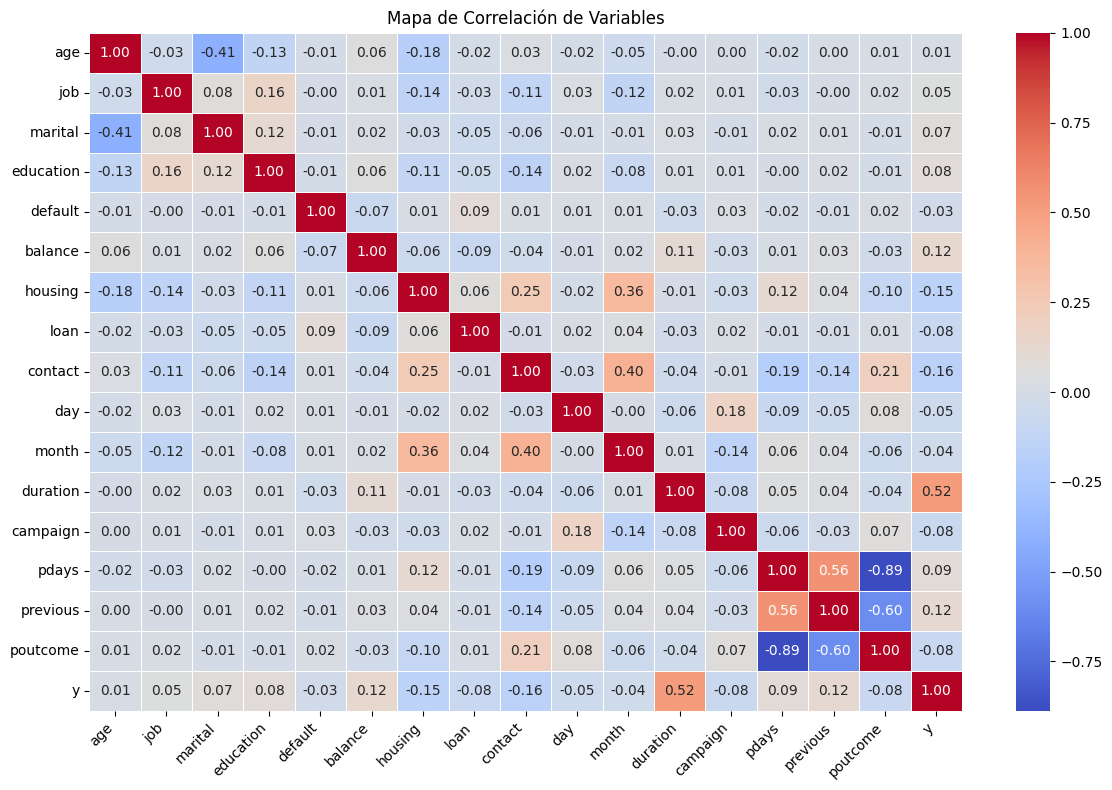

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Elimina la columna de ID antes del análisis
df_corr = df.drop(columns=['id'])

# Calcula la matriz de correlación
correlation_matrix = df_corr.corr()

# Gráfica del mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Correlación de Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Normalization with MinMaxScaler**

In [18]:
#minmax
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# except id
df_scaled = scaler.fit_transform(df.drop(columns=['id']))
df_scaled = pd.DataFrame(df_scaled, columns=df.columns[1:])
df_scaled['id'] = df['id']
df_scaled

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,id
0,0.311688,0.818182,0.5,0.333333,0.0,0.074497,0.0,0.0,0.0,0.800000,0.090909,0.023592,0.032258,0.000000,0.000,1.0,0.0,0
1,0.259740,0.090909,0.5,0.333333,0.0,0.079203,0.0,0.0,1.0,0.566667,0.545455,0.037421,0.000000,0.000000,0.000,1.0,0.0,1
2,0.233766,0.090909,0.5,0.333333,0.0,0.080020,1.0,0.0,1.0,0.433333,0.727273,0.022371,0.016129,0.000000,0.000,1.0,0.0,2
3,0.116883,0.727273,1.0,0.333333,0.0,0.074748,1.0,0.0,1.0,0.900000,0.727273,0.001830,0.016129,0.000000,0.000,1.0,0.0,3
4,0.103896,0.818182,0.5,0.333333,0.0,0.082684,1.0,0.0,0.0,0.066667,0.272727,0.183242,0.000000,0.000000,0.000,1.0,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,0.142857,0.636364,1.0,0.333333,0.0,0.086331,0.0,1.0,1.0,0.100000,0.454545,0.204393,0.016129,0.000000,0.000,1.0,1.0,749995
749996,0.662338,0.454545,0.0,0.666667,0.0,0.080289,0.0,0.0,0.0,0.600000,0.090909,0.017490,0.000000,0.000000,0.000,1.0,0.0,749996
749997,0.415584,0.090909,0.5,0.333333,0.0,0.076446,1.0,0.0,0.0,0.533333,0.000000,0.022778,0.000000,0.000000,0.000,1.0,0.0,749997
749998,0.181818,0.818182,0.5,0.333333,0.0,0.071889,0.0,0.0,0.0,0.833333,0.090909,0.021761,0.080645,0.000000,0.000,1.0,0.0,749998


**Best Features**

In [19]:
# Features uding Chi2
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.datasets import load_iris

X = df_scaled.drop(columns=['id','y'])
y = df_scaled['y']

# Select the top 5 features using chi-squared test --Change k features--
selector = SelectKBest(chi2, k=2)
X_new = selector.fit_transform(X, y)

print("Original features shape:", X.shape)
print("Selected features shape:", X_new.shape)
print("Selected features:", X.columns[selector.get_support()])

Original features shape: (750000, 16)
Selected features shape: (750000, 2)
Selected features: Index(['contact', 'duration'], dtype='object')


In [20]:
# Recursive Feature Elimination
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

X = df_scaled.drop(columns=['id','y'])
y = df_scaled['y']

# Apply RFE with logistic regression
model = LogisticRegression()
rfe = RFE(model, n_features_to_select=2)
X_train_rfe = rfe.fit_transform(X, y)

print("Selected features:", X.columns[rfe.get_support()])

Selected features: Index(['duration', 'previous'], dtype='object')


In [21]:
# Tree-Based Feature Importance
from sklearn.ensemble import RandomForestClassifier

X = df_scaled.drop(columns=['id','y'])
y = df_scaled['y']

# Train random forest and get feature importances
model = RandomForestClassifier()
model.fit(X, y)
importances = model.feature_importances_

# Display feature importances
feature_importances = pd.Series(importances, index=X.columns)
print(feature_importances.sort_values(ascending=False))

duration     0.402225
balance      0.124467
age          0.087243
day          0.071987
month        0.068056
job          0.036948
poutcome     0.033684
campaign     0.031616
pdays        0.031312
housing      0.029722
contact      0.024309
education    0.019698
marital      0.016096
previous     0.012732
loan         0.009025
default      0.000880
dtype: float64


**Models**:
- Logistic Regression
- Decision Trees
- Random Forest
- SVM
- Neural Networks
- Naive Bayes
- K-Nearest Neighbors
- Gradient Boosting
- XGBoost

# **Best Model**

Undersampled class distribution: Counter({0.0: 90488, 1.0: 90488})
Accuracy: 0.9007625151950491
roc_auc_score 0.9004670088378781
              precision    recall  f1-score   support

         0.0       0.93      0.87      0.90     17927
         1.0       0.88      0.93      0.90     18269

    accuracy                           0.90     36196
   macro avg       0.90      0.90      0.90     36196
weighted avg       0.90      0.90      0.90     36196



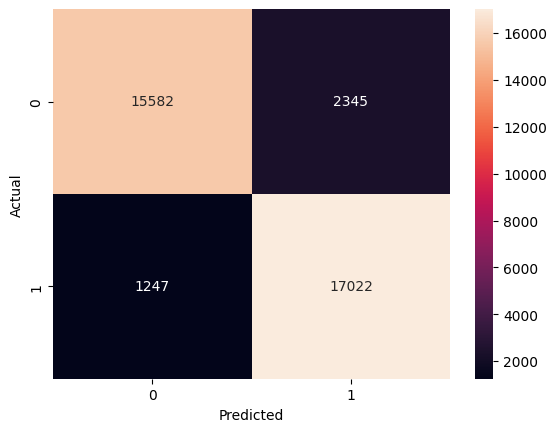

In [26]:
# Random Forest
# Balanced with # Undersampling using RandomUnderSampler
import numpy as np
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

X = df_scaled.drop(columns=['id','y'])
y = df_scaled['y']

undersample = RandomUnderSampler(sampling_strategy='majority')
X_under, y_under = undersample.fit_resample(X, y)
print("Undersampled class distribution:", Counter(y_under))

#Best hyperparameters are {'max_depth': 100, 'max_features': 10, 'min_samples_leaf': 4, 'n_estimators': 100}
#Best score is: 0.9011968452093626

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_under['id'] = df['id']
X = X_under.drop(columns=['id'])
y = y_under

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(max_depth=100, max_features=10, min_samples_leaf=4, n_estimators=100,class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# roc_auc_score
from sklearn.metrics import roc_auc_score
print('roc_auc_score',roc_auc_score(y_test, y_pred))

# f1-score
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**PREDICTION**

In [34]:
test = pd.read_csv('/content/train/test.csv')
print(test.head())

# change all categorical features with label encoder
for col in test.select_dtypes(include=['object']):
    test[col] = le.fit_transform(test[col])

#normalice with minmax
test_scaled = scaler.fit_transform(test.drop(columns=['id']))
test_scaled = pd.DataFrame(test_scaled, columns=test.columns[1:])
test_scaled['id'] = test['id']
print(test_scaled.head())

#predict y with decimals example 0.05, 0.15
test_scaled['y'] = model.predict_proba(test_scaled.drop(columns=['id']))[:,1]
test_scaled.head()

       id  age            job  marital  education default  balance housing  \
0  750000   32    blue-collar  married  secondary      no     1397     yes   
1  750001   44     management  married   tertiary      no       23     yes   
2  750002   36  self-employed  married    primary      no       46     yes   
3  750003   58    blue-collar  married  secondary      no    -1380     yes   
4  750004   28     technician   single  secondary      no     1950     yes   

  loan   contact  day month  duration  campaign  pdays  previous poutcome  
0   no   unknown   21   may       224         1     -1         0  unknown  
1   no  cellular    3   apr       586         2     -1         0  unknown  
2  yes  cellular   13   may       111         2     -1         0  unknown  
3  yes   unknown   29   may       125         1     -1         0  unknown  
4   no  cellular   22   jul       181         1     -1         0  unknown  
        age       job  marital  education  default   balance  housing  loan

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,id,y
0,0.181818,0.090909,0.5,0.333333,0.0,0.088383,1.0,0.0,1.0,0.666667,0.727273,0.044964,0.000000,0.0,0.0,1.0,750000,0.009973
1,0.337662,0.363636,0.5,0.666667,0.0,0.075486,1.0,0.0,0.0,0.066667,0.000000,0.118616,0.017544,0.0,0.0,1.0,750001,0.445036
2,0.233766,0.545455,0.5,0.000000,0.0,0.075702,1.0,1.0,0.0,0.400000,0.727273,0.021974,0.017544,0.0,0.0,1.0,750002,0.012044
3,0.519481,0.090909,0.5,0.333333,0.0,0.062317,1.0,1.0,1.0,0.933333,0.727273,0.024822,0.000000,0.0,0.0,1.0,750003,0.000000
4,0.129870,0.818182,1.0,0.333333,0.0,0.093574,1.0,0.0,0.0,0.700000,0.454545,0.036216,0.000000,0.0,0.0,1.0,750004,0.101333


In [36]:
# save as csv
test_csv = test_scaled[['id','y']]
test_csv.to_csv('test_csv.csv', index=False)

# Experiments

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ['contact', 'duration'] CHI,  acc = 0.84 , roc = 0.80, f1 =0.91,0.54
# duration, balance RFE,  acc = 0.81 , roc = 0.78, f1 =0.89,0.50
# ['duration', 'previous'] RF,  acc = 0.81 , roc = 0.79, f1 =0.89,0.51

# X = df_scaled.drop(columns=['id','y'])
X = df_scaled[['duration', 'contact']]
y = df_scaled['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# add class_weight=’balanced’

model = LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# f1-score
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# using all features acc = 0.90 roc_auc = 0.69



In [ ]:
# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

In [ ]:
# Decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ['contact', 'duration'] CHI  acc = 0.83 , roc = 0.86, f1 =0.90,0.57
# duration, balance RFE  acc = 0.87 , roc = 0.74, f1 = 0.93,0.52
# ['duration', 'previous'] RF  acc = 0.82 , roc = 0.85, f1 = 0.89,0.55

# X = df_scaled.drop(columns=['id','y'])
X = df_scaled[['duration', 'previous']]
y = df_scaled['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# f1-score
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ['contact', 'duration'] CHI  acc = 0.83 , roc = 0.86, f1 =0.90,0.57
# duration, balance RFE  acc = 0.88 , roc = 0.74, f1 = 0.94,0.55
# ['duration', 'previous'] RF  acc = 0.82 , roc = 0.84, f1 = 0.89,0.55

# X = df_scaled.drop(columns=['id','y'])
X = df_scaled[['duration', 'previous']]
y = df_scaled['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# f1-score
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

In [ ]:
# # SVM
# from sklearn.svm import SVC
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# # ['contact', 'duration'] CHI  acc = 0.83 , roc = 0.86, f1 =0.90,0.57
# # duration, balance RFE  acc = 0.87 , roc = 0.74, f1 = 0.93,0.52
# # ['duration', 'previous'] RF  acc = 0.82 , roc = 0.85, f1 = 0.89,0.55

# # X = df_scaled.drop(columns=['id','y'])
# X = df_scaled[['duration', 'contact']]
# y = df_scaled['y']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model = SVC(class_weight='balanced')
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy:", accuracy)

# # f1-score
# print(classification_report(y_test, y_pred))

# # confusion matrix
# cm = confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()

In [ ]:
# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

In [ ]:

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ['contact', 'duration'] CHI  acc = 0.88 , roc = 0.70, f1 =0.90,0.57
# duration, balance RFE  acc = 0.89 , roc = 0.57, f1 = 0.94,0.27
# ['duration', 'previous'] RF  acc = 0.87 , roc = 0.5, f1 = 0.94,0.0

X = df_scaled.drop(columns=['id','y'])
#X = df_scaled[['duration', 'previous']]
y = df_scaled['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = tf.keras.utils.normalize(X_train, axis=1)
X_test = tf.keras.utils.normalize(X_test, axis=1)
# Removed normalization of y_train and y_test
# y_train = tf.keras.utils.normalize(y_train, axis=1)
# y_test = tf.keras.utils.normalize(y_test, axis=1)

model = tf.keras.models.Sequential()

# 3 layers
model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(2, activation=tf.nn.softmax))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=3)

val_loss, val_acc = model.evaluate(X_test, y_test)
print(val_loss, val_acc)

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# f1
print(classification_report(y_test, y_pred))

In [ ]:
# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

In [ ]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ['contact', 'duration'] CHI  acc = 0.89 , roc = 0.70, f1 =0.94,0.50
# duration, balance RFE  acc = 0.88 , roc = 0.68, f1 = 0.94,0.46
# ['duration', 'previous'] RF  acc = 0.88 , roc = 0.68, f1 = 0.94,0.47

# X = df_scaled.drop(columns=['id','y'])
X = df_scaled[['duration', 'previous']]
y = df_scaled['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#f1
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

In [ ]:
# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# ['contact', 'duration'] CHI  acc = 0.89 , roc = 0.71, f1 =0.94,0.53
# duration, balance RFE  acc = 0.89 , roc = 0.71, f1 = 0.94,0.53
# ['duration', 'previous'] RF  acc = 0.89 , roc = 0.71, f1 = 0.94,0.53

# X = df_scaled.drop(columns=['id','y'])
X = df_scaled[['duration', 'previous']]
y = df_scaled['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#f1
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)


In [ ]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# ['contact', 'duration'] CHI  acc = 0.89 , roc = 0.64, f1 =0.90,0.57
# duration, balance RFE  acc = 0.87 , roc = 0.74, f1 = 0.93,0.52
# ['duration', 'previous'] RF  acc = 0.82 , roc = 0.85, f1 = 0.89,0.55

# X = df_scaled.drop(columns=['id','y'])
X = df_scaled[['duration', 'contact']]
y = df_scaled['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=4)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#f1
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

In [ ]:
# XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# ['contact', 'duration'] CHI  acc = 0.83 , roc = 0.86, f1 =0.90,0.57
# duration, balance RFE  acc = 0.87 , roc = 0.74, f1 = 0.93,0.52
# ['duration', 'previous'] RF  acc = 0.82 , roc = 0.85, f1 = 0.89,0.55

# X = df_scaled.drop(columns=['id','y'])
X = df_scaled[['duration', 'contact']]
y = df_scaled['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=4)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#f1
print(classification_report(y_test, y_pred))
#confussion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

**With 3 features and balanced**

In [ ]:
# Balanced with # Undersampling using RandomUnderSampler
import numpy as np
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

X = df_scaled.drop(columns=['id','y'])
y = df_scaled['y']

undersample = RandomUnderSampler(sampling_strategy='majority')
X_under, y_under = undersample.fit_resample(X, y)
print("Undersampled class distribution:", Counter(y_under))

In [ ]:
X_under['id'] = df['id']
X_under
y_under

# **New modeling with undersampled data**

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ['contact', 'duration'] CHI,  acc = 0.80 , roc = 0.80, f1 =0.81,0.79
# duration, balance RFE,  acc = 0.78 , roc = 0.78, f1 =0.79,0.78
# ['duration', 'previous'] RF,  acc = 0.79 , roc = 0.79, f1 =0.80,0.79

# X = X_under.drop(columns=['id'])
X = X_under[['duration', 'previous']]
y = y_under

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# add class_weight=’balanced’

model = LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#f1
print(classification_report(y_test, y_pred))
#confussion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

# results with all features
# acc = 0.85
# f1 0.85,0.85
# roc 0.85

In [ ]:
# Decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ['contact', 'duration'] CHI,  acc = 0.86 , roc = 0.86, f1 =0.86,0.87
# duration, balance RFE,  acc = 0.81 , roc = 0.81, f1 =0.81,0.82
# ['duration', 'previous'] RF,  acc = 0.85 , roc = 0.85, f1 =0.85,0.86

#X = X_under.drop(columns=['id'])
X = X_under[['duration', 'previous']]
y = y_under

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#f1
print(classification_report(y_test, y_pred))
#confussion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

# results with all features
# acc = 0.85
# f1 0.85,0.85
# roc 0.85

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ['contact', 'duration'] CHI,  acc = 0.86 , roc = 0.86, f1 =0.86,0.87
# duration, balance RFE,  acc = 0.84 , roc = 0.84, f1 =0.83,0.85
# ['duration', 'previous'] RF,  acc = 0.85 , roc = 0.85, f1 =0.85,0.86

#X = X_under.drop(columns=['id'])
X = X_under[['duration', 'previous']]
y = y_under

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#f1
print(classification_report(y_test, y_pred))
#confussion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

# results with all features
# acc = 0.90
# f1 0.90,0.90
# roc 0.89

In [ ]:
# # SVM
# from sklearn.svm import SVC
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# # ['contact', 'duration'] CHI,  acc = 0.86 , roc = 0.86, f1 =0.86,0.87
# # duration, balance RFE,  acc = 0.84 , roc = 0.84, f1 =0.83,0.85
# # ['duration', 'previous'] RF,  acc = 0.85 , roc = 0.85, f1 =0.85,0.86

# X = X_under.drop(columns=['id'])
# #X = X_under[['duration', 'previous']]
# y = y_under

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model = SVC(class_weight='balanced')
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy:", accuracy)

# #f1
# print(classification_report(y_test, y_pred))
# #confussion matrix
# cm = confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()

# # roc_auc_score
# from sklearn.metrics import roc_auc_score
# roc_auc_score(y_test, y_pred)

# # results with all features
# # acc = 0.90
# # f1 0.90,0.90
# # roc 0.89

In [ ]:

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ['contact', 'duration'] CHI,  acc = 0.86 , roc = 0.86, f1 =0.86,0.87
# duration, balance RFE,  acc = 0.84 , roc = 0.84, f1 =0.83,0.85
# ['duration', 'previous'] RF,  acc = 0.85 , roc = 0.85, f1 =0.85,0.86

X = X_under.drop(columns=['id'])
#X = X_under[['duration', 'previous']]
y = y_under

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = tf.keras.utils.normalize(X_train, axis=1)
X_test = tf.keras.utils.normalize(X_test, axis=1)
# Removed normalization of y_train and y_test
# y_train = tf.keras.utils.normalize(y_train, axis=1)
# y_test = tf.keras.utils.normalize(y_test, axis=1)

model = tf.keras.models.Sequential()

# 3 layers
model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(2, activation=tf.nn.softmax))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=3)

val_loss, val_acc = model.evaluate(X_test, y_test)
print(val_loss, val_acc)

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#f1
print(classification_report(y_test, y_pred))

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

# results with all features
# acc = 0.88
# f1 0.87,0.89
# roc 0.88

# Low results

In [ ]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ['contact', 'duration'] CHI,  acc = 0.86 , roc = 0.86, f1 =0.86,0.87
# duration, balance RFE,  acc = 0.84 , roc = 0.84, f1 =0.83,0.85
# ['duration', 'previous'] RF,  acc = 0.85 , roc = 0.85, f1 =0.85,0.86

#X = X_under.drop(columns=['id'])
X = X_under[['duration', 'previous']]
y = y_under

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#f1
print(classification_report(y_test, y_pred))
#confussion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

# results with all features
# acc = 0.81
# f1 0.81,0.83
# roc 0.89.

# **Best performance**

**Random forest with all features and undersampling data**

In [ ]:
# grid search
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = X_under.drop(columns=['id'])
#X = X_under[['duration', 'previous']]
y = y_under

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#f1
print(classification_report(y_test, y_pred))
#confussion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

rf_grid = RandomForestClassifier()
gr_space = {
    'max_depth': [5,50,100],
    'n_estimators': [10, 50, 100],
    'max_features': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(rf_grid, gr_space, cv = 3, scoring='accuracy', verbose = 3)
model_grid = grid.fit(X, y)

print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))

#Best hyperparameters are {'max_depth': 100, 'max_features': 10, 'min_samples_leaf': 4, 'n_estimators': 100}
#Best score is: 0.9011968452093626

Best Features for RNA

In [ ]:
!pip install scikeras

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier

# ==== Seed for reproducibility ====
seed = 7
np.random.seed(seed)
tf.random.set_seed(seed)

# ==== Example dataset (replace with your data) ====
# X and y must be NumPy arrays
# X.shape -> (samples, features)
# y.shape -> (samples,)
X = X_under.drop(columns=['id']).values
y = y_under.values

# ==== Model builder function ====
def create_model(neurons=12, activation='relu'):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(X.shape[1],)))
    model.add(Dense(1, activation='sigmoid'))  # binary output
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# ==== Wrap with SciKeras ====
model = KerasClassifier(model=create_model, verbose=0)

# ==== Grid parameters ====
param_grid = {
    "model__neurons": [8, 12, 16],
    "model__activation": ['relu', 'tanh'],
    "batch_size": [10, 20, 40],
    "epochs": [10, 50]
}

# ==== Grid Search ====
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1)
grid_result = grid.fit(X, y)

# ==== Results ====
print(f"Best: {grid_result.best_score_:.4f} using {grid_result.best_params_}")
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print(f"{mean:.4f} ({stdev:.4f}) with: {param}")



In [ ]:
# !pip install --upgrade scikeras
! pip install --upgrade scikeras scikit-learn tensorflow


In [ ]:
!pip install --upgrade scikeras

In [ ]:
!pip install keras-tuner

In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_1', min_value=32, max_value=512, step=32), activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(units=hp.Int('units_2', min_value=32, max_value=512, step=32), activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
# Choose and configure a tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of hyperparameter combinations to try
    executions_per_trial=3,  # Number of models to train per trial
    directory='my_dir',
    project_name='keras_tuning')

# Run the search
tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The optimal number of units in the first hidden layer is {best_hps.get('units_1')} and in the second hidden layer is {best_hps.get('units_2')}.
The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")